Episode 1/100 - Total Delay = 2.3310e+01 s, Total Price = 1.9830e+02 $
Episode 2/100 - Total Delay = 1.4800e+01 s, Total Price = 1.8164e+02 $
Episode 3/100 - Total Delay = 2.0606e+01 s, Total Price = 1.8761e+02 $
Episode 4/100 - Total Delay = 1.8047e+01 s, Total Price = 1.8366e+02 $
Episode 5/100 - Total Delay = 1.6941e+01 s, Total Price = 1.8353e+02 $
Episode 6/100 - Total Delay = 2.2184e+01 s, Total Price = 1.6614e+02 $
Episode 7/100 - Total Delay = 1.4122e+01 s, Total Price = 1.9190e+02 $
Episode 8/100 - Total Delay = 1.8277e+01 s, Total Price = 1.9496e+02 $
Episode 9/100 - Total Delay = 1.7383e+01 s, Total Price = 1.9313e+02 $
Episode 10/100 - Total Delay = 1.5875e+01 s, Total Price = 1.8224e+02 $
Episode 11/100 - Total Delay = 1.6858e+01 s, Total Price = 1.8702e+02 $
Episode 12/100 - Total Delay = 1.6258e+01 s, Total Price = 1.7528e+02 $
Episode 13/100 - Total Delay = 1.8126e+01 s, Total Price = 1.7840e+02 $
Episode 14/100 - Total Delay = 1.9802e+01 s, Total Price = 1.8838e+02 $
E

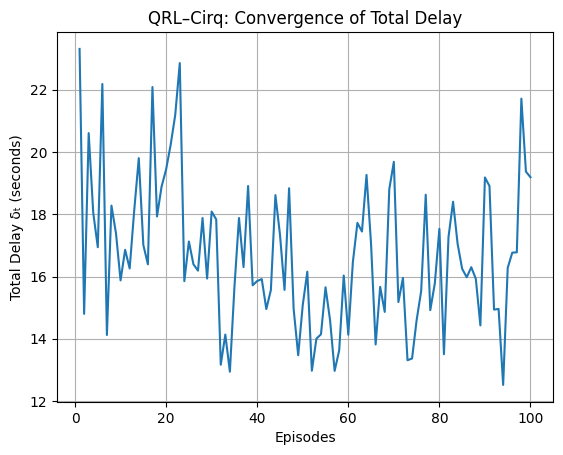

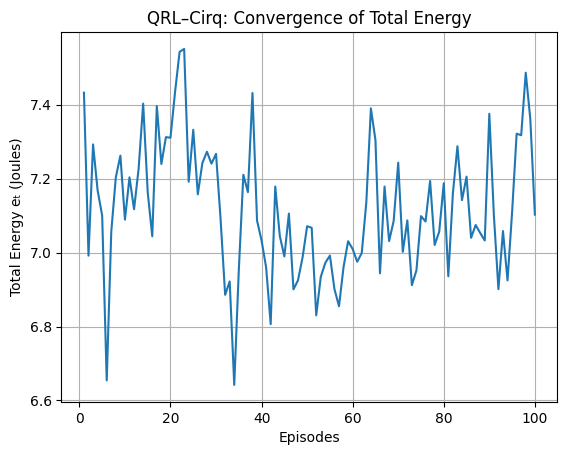

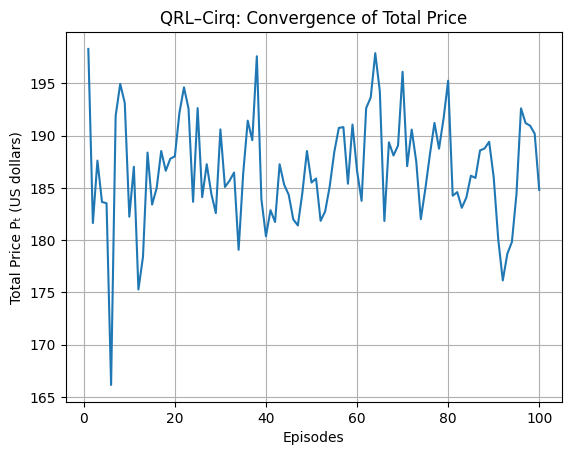

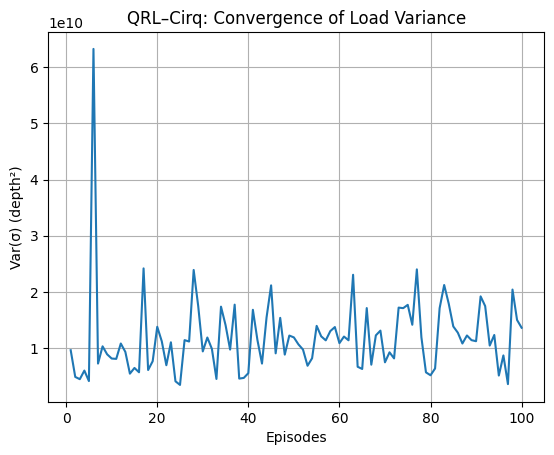

In [2]:
import numpy as np
import random
from copy import deepcopy
import matplotlib.pyplot as plt
import cirq


# ============================================================
#  SEEDED TABLE-6 PARAMETER GENERATOR
# ============================================================

def get_seeded_table6_parameters(M=100, N=5, seed=42):
    """
    Generate random-but-repeatable parameters based on Table 6 ranges.
    M : number of tasks
    N : number of quantum nodes
    """
    np.random.seed(seed)
    random.seed(seed)

    def r(a, b, size=None):
        return np.random.uniform(a, b, size)

    # From Table 6:
    # n_j^q : 2.2e7 – 9e7 (node quantum capacity-like parameter)
    nq_j = r(2.2e7, 9e7, N)

    # φ_z^r : 2.2e7 – 9e7 (can be mapped to CLOPS)
    phi_z_r = r(2.2e7, 9e7, N)

    # φ_z^T : 5000 seconds (global threshold time)
    phi_z_T = 5000.0

    # φ_g^d : 1.5e4 – 2.9e4 (circuit depth)
    phi_g_d = r(1.5e4, 2.9e4, M)

    # n_j^z : 700 – 1500 (can scale qubit requirement / capacity)
    n_j_z = r(700, 1500, N)

    # P_j : 2e4 – 9e7 (not directly used as price here, but kept)
    P_j = r(2e4, 9e7, N)

    # φ_g^s : 1000 – 1050 (shots)
    phi_g_s = r(1000, 1050, M)

    # ρ_j : $1 – $3 per second
    rho_j = r(1, 3, N)

    # φ_ε* : 2.2e7 – 9e7
    phi_epsilon_star = float(r(2.2e7, 9e7))

    params = {
        "M": M,
        "N": N,
        "nq_j": nq_j,
        "phi_z_r": phi_z_r,
        "phi_z_T": phi_z_T,
        "phi_g_d": phi_g_d,
        "n_j_z": n_j_z,
        "P_j": P_j,
        "phi_g_s": phi_g_s,
        "rho_j": rho_j,
        "phi_epsilon_star": phi_epsilon_star
    }
    return params


# ============================================================
#  TASK & NODE DEFINITIONS
# ============================================================

class QuantumTask:
    def __init__(self, depth, shots, qubits, deadline, max_price):
        self.d = depth      # circuit depth (dimensionless gate layers)
        self.s = shots      # number of shots (repetitions)
        self.q = qubits     # qubits required (dimensionless count)
        self.T = deadline   # deadline (seconds)
        self.P = max_price  # max acceptable price ($)


class QuantumNode:
    def __init__(self, qubits, clo_ps, price_rate, power):
        self.q = qubits         # available qubits (dimensionless)
        self.s = clo_ps         # CLOPS (circuit layer operations / second)
        self.rho = price_rate   # price rate ($ / second)
        self.power = power      # power per qubit (Watts / qubit ≈ J/s per qubit)
        self.topology = "Topo-1"
        self.volume = 100       # placeholder


# ============================================================
#  QTO ENVIRONMENT
# ============================================================

class QTOEnvironment:

    def __init__(self, tasks, nodes, weights, penalties):
        self.tasks = tasks
        self.nodes = nodes
        self.M = len(tasks)
        self.N = len(nodes)

        self.w_delay, self.w_energy, self.w_load, self.w_price = weights
        self.lambda_delay, self.lambda_price, self.lambda_qubit = penalties

        # Precompute normalization upper bounds
        self.delta_m = self.max_delay_upper_bound()
        self.energy_m = self.max_energy_upper_bound()
        self.price_m = self.max_price_upper_bound()
        self.load_m = self.max_load_upper_bound()

    # ---------------- METRIC COMPUTATION ----------------

    def compute_metrics(self, xi):
        """
        xi: M x N offloading matrix (binary), each row sums to 1.
        Returns physical metrics + normalized versions.
        """

        M, N = self.M, self.N

        total_delay = np.zeros(M)   # seconds
        comp_delay = np.zeros(M)    # seconds
        load = np.zeros(N)          # sum of depths (dimensionless)
        urgency_penalty = 0.0

        flag_price = 0
        flag_qubit = 0

        total_energy = 0.0  # Joules (approx)
        total_price = 0.0   # $

        node_wait = {j: [] for j in range(N)}

        # 1. Computation delay for each task
        for g in range(M):
            j = int(np.argmax(xi[g]))
            task = self.tasks[g]
            node = self.nodes[j]
            comp_delay[g] = (task.d * task.s) / node.s  # seconds

        # 2. Urgency values
        urgency = np.zeros(M)
        for g in range(M):
            T = self.tasks[g]
            if T.T > comp_delay[g]:
                urgency[g] = 1.0 / (T.T - comp_delay[g])  # 1/second
            else:
                urgency[g] = 1e4  # extremely urgent / infeasible

        sorted_idx = np.argsort(urgency)

        # 3. Final metrics (processed in increasing urgency)
        for g in sorted_idx:
            j = int(np.argmax(xi[g]))
            T = self.tasks[g]
            Nj = self.nodes[j]

            delta_c = comp_delay[g]  # seconds

            # qubit capacity violation
            if T.q > Nj.q:
                flag_qubit += 1

            # waiting delay
            wait_delay = sum(node_wait[j])  # seconds
            total_delay[g] = delta_c + wait_delay

            node_wait[j].append(delta_c)

            # deadline violation penalty
            if total_delay[g] > T.T:
                urgency_penalty += urgency[g]

            # energy (Joules ≈ power[W]*time[s]*qubits)
            total_energy += delta_c * T.q * Nj.power

            # price ($)
            cost = Nj.rho * delta_c
            total_price += cost
            if cost > T.P:
                flag_price += 1

            # load (circuit depth)
            load[j] += T.d

        delta_t = float(np.max(total_delay))      # seconds
        load_var = float(np.var(load))           # depth^2

        # Normalized metrics \in [0, ∞), but we cap in cost
        delta_norm = delta_t / self.delta_m if self.delta_m > 0 else 0.0
        energy_norm = total_energy / self.energy_m if self.energy_m > 0 else 0.0
        price_norm = total_price / self.price_m if self.price_m > 0 else 0.0
        load_norm = load_var / self.load_m if self.load_m > 0 else 0.0

        metrics = {
            "delta_t": delta_t,            # seconds
            "energy_t": total_energy,      # Joules
            "price_t": total_price,        # $
            "load_var": load_var,          # depth^2
            "delta_norm": delta_norm,
            "energy_norm": energy_norm,
            "price_norm": price_norm,
            "load_norm": load_norm,
            "flag_price": flag_price,
            "flag_qubit": flag_qubit,
            "urgency_penalty": urgency_penalty,
        }
        return metrics

    # ---------------- REWARD FUNCTION ----------------

    def compute_reward(self, xi):
        m = self.compute_metrics(xi)

        C = (
            self.w_delay * min(1.0, m["delta_norm"]) +
            self.w_energy * min(1.0, m["energy_norm"]) +
            self.w_load * min(1.0, m["load_norm"]) +
            self.w_price * min(1.0, m["price_norm"])
        )

        R = (
            1.0 - C
            - self.lambda_delay * m["urgency_penalty"]
            - self.lambda_price * m["flag_price"]
            - self.lambda_qubit * m["flag_qubit"]
        )

        # squash to stable range [-1, 1]
        return float(np.tanh(R))

    # ---------------- UPPER BOUNDS FOR NORMALIZATION ----------------

    def max_delay_upper_bound(self):
        slow = min(self.nodes, key=lambda x: x.s)
        return sum((T.d * T.s) / slow.s for T in self.tasks)

    def max_energy_upper_bound(self):
        slow = min(self.nodes, key=lambda x: x.s)
        return sum(((T.d * T.s) / slow.s) * T.q * slow.power for T in self.tasks)

    def max_price_upper_bound(self):
        slow = min(self.nodes, key=lambda x: x.s)
        rho_max = max(n.rho for n in self.nodes)
        return sum(rho_max * (T.d * T.s) / slow.s for T in self.tasks)

    def max_load_upper_bound(self):
        return sum(T.d for T in self.tasks)


# ============================================================
#  QRL AGENT WITH CIRQ-BASED GROVER
# ============================================================

class QRLAgentCirq:

    def __init__(
        self,
        env,
        alpha=0.2,
        gamma=0.8,
        grover_scale=1.0,
        max_grover_iter=3,
        seed=42
    ):
        self.env = env
        self.M, self.N = env.M, env.N

        self.alpha = alpha
        self.gamma = gamma
        self.grover_scale = grover_scale
        self.max_grover_iter = max_grover_iter

        random.seed(seed)
        np.random.seed(seed)

        # Q(s_{i,j}, a_{i,k}) shape (M, N, N)
        self.Q = np.zeros((self.M, self.N, self.N), dtype=np.float64)

        # Quantum action register: q = ceil(log2 N) qubits
        self.n_qubits = int(np.ceil(np.log2(self.N)))
        self.dim = 2 ** self.n_qubits
        self.qubits = cirq.LineQubit.range(self.n_qubits)

        # Initial |A_i(0)> = H^{⊗q}|0...0>
        self.initial_action_state = self._build_initial_action_state()

        # β_{i,:} = statevector for each task
        self.beta = np.zeros((self.M, self.dim), dtype=np.complex128)
        for i in range(self.M):
            self.beta[i] = self.initial_action_state.copy()

        # Precompute Grover unitaries for each action index k
        self.grover_unitaries = self._precompute_grover_unitaries()

    # ---------------- Build Uniform Superposition ----------------

    def _build_initial_action_state(self):
        init = np.zeros(self.dim, dtype=np.complex128)
        init[0] = 1.0
        circuit = cirq.Circuit(cirq.H.on_each(*self.qubits))
        U = cirq.unitary(circuit)
        psi = U @ init
        psi /= np.linalg.norm(psi)
        return psi

    # ---------------- Oracle & Diffusion in Cirq ----------------

    def _oracle_circuit(self, marked_state):
        bits = format(marked_state, f"0{self.n_qubits}b")
        circuit = cirq.Circuit()

        for qb, b in zip(self.qubits, bits):
            if b == '0':
                circuit.append(cirq.X(qb))

        if self.n_qubits == 1:
            circuit.append(cirq.Z(self.qubits[0]))
        else:
            circuit.append(cirq.Z(self.qubits[-1]).controlled_by(*self.qubits[:-1]))

        for qb, b in zip(self.qubits, bits):
            if b == '0':
                circuit.append(cirq.X(qb))

        return circuit

    def _diffusion_circuit(self):
        circuit = cirq.Circuit()
        circuit.append(cirq.H.on_each(*self.qubits))
        circuit.append(cirq.X.on_each(*self.qubits))

        if self.n_qubits == 1:
            circuit.append(cirq.Z(self.qubits[0]))
        else:
            circuit.append(cirq.Z(self.qubits[-1]).controlled_by(*self.qubits[:-1]))

        circuit.append(cirq.X.on_each(*self.qubits))
        circuit.append(cirq.H.on_each(*self.qubits))
        return circuit

    def _precompute_grover_unitaries(self):
        unitaries = []
        for k in range(self.N):
            circuit = cirq.Circuit()
            circuit += self._oracle_circuit(k)
            circuit += self._diffusion_circuit()
            U = cirq.unitary(circuit).astype(np.complex128)
            unitaries.append(U)
        return unitaries

    # ---------------- Apply Grover Iterations ----------------

    def _apply_grover(self, i, marked_action, F):
        U = self.grover_unitaries[marked_action]
        psi = self.beta[i]
        for _ in range(F):
            psi = U @ psi
        psi /= np.linalg.norm(psi)
        self.beta[i] = psi

    # ---------------- TRAINING LOOP ----------------

    def train(self, episodes=100):

        M, N = self.M, self.N

        # Offloading matrix ξ: initially all tasks on last node
        xi = np.zeros((M, N), dtype=int)
        xi[:, N - 1] = 1

        history = {"delay": [], "energy": [], "price": [], "load_var": []}

        for ep in range(episodes):

            # Inner loop over tasks
            for i in range(M):
                j = int(np.argmax(xi[i]))  # current node

                # 1) Action selection using quantum amplitudes β_i
                probs_full = np.abs(self.beta[i]) ** 2
                probs = probs_full[:N].copy()
                probs /= probs.sum() if probs.sum() > 0 else 1.0

                k_prime = np.random.choice(N, p=probs)

                # 2) Temporary offloading
                temp_xi = deepcopy(xi)
                temp_xi[i, :] = 0
                temp_xi[i, k_prime] = 1

                # 3) Reward
                R = self.env.compute_reward(temp_xi)

                # 4) Q-update
                old_q = self.Q[i, j, k_prime]
                max_next = np.max(self.Q[i, k_prime, :])
                td_target = R + self.gamma * max_next
                self.Q[i, j, k_prime] = old_q + self.alpha * (td_target - old_q)

                # 5) Grover iteration count
                base_val = max(0.0, R + self.Q[i, j, k_prime])
                F = int(self.grover_scale * base_val)
                F = max(1, min(self.max_grover_iter, F))

                # Mark the action with highest Q-value at state s_{i,j}
                best_action = int(np.argmax(self.Q[i, j, :]))
                self._apply_grover(i, best_action, F)

            # Outer step: final offloading decision using argmax |β_{i,k}|^2
            new_xi = np.zeros((M, N), dtype=int)
            for i in range(M):
                probs_full = np.abs(self.beta[i]) ** 2
                best_k = int(np.argmax(probs_full[:N]))
                new_xi[i, best_k] = 1
            xi = new_xi

            # Log metrics after each episode
            m = self.env.compute_metrics(xi)
            history["delay"].append(m["delta_t"])
            history["energy"].append(m["energy_t"])
            history["price"].append(m["price_t"])
            history["load_var"].append(m["load_var"])

            print(f"Episode {ep+1}/{episodes} "
                  f"- Total Delay = {m['delta_t']:.4e} s, "
                  f"Total Price = {m['price_t']:.4e} $")

        return xi, self.Q, self.beta, history


# ============================================================
#  BUILD TASKS & NODES FROM SEEDED TABLE-6 PARAMS
# ============================================================

def build_tasks_and_nodes_from_table6(seed=42, M=100, N=5):
    params = get_seeded_table6_parameters(M=M, N=N, seed=seed)

    M = params["M"]
    N = params["N"]

    tasks = []
    for i in range(M):
        depth = params["phi_g_d"][i]          # 1.5e4 – 2.9e4
        shots = params["phi_g_s"][i]          # 1000 – 1050
        qubits = random.randint(3, 12)        # not in table; reasonable range
        deadline = params["phi_z_T"]          # 5000 s
        max_price = random.uniform(10, 30)    # $; not in table, but needed
        tasks.append(QuantumTask(depth, shots, qubits, deadline, max_price))

    nodes = []
    for j in range(N):
        # map huge table values to reasonable qubit counts and CLOPS scale
        qubits = int(params["nq_j"][j] / 1e6)      # scale 2.2e7–9e7 → ~20–90 qubits
        clo_ps = params["phi_z_r"][j]              # ~2.2e7–9e7 CLOPS
        price_rate = params["rho_j"][j]            # $/s
        power = 0.01                               # W/qubit (J/s per qubit)
        nodes.append(QuantumNode(qubits, clo_ps, price_rate, power))

    return tasks, nodes


# ============================================================
#  MAIN SIMULATION
# ============================================================

if __name__ == "__main__":

    # Global seed: ensures everything is repeatable
    GLOBAL_SEED = 123
    np.random.seed(GLOBAL_SEED)
    random.seed(GLOBAL_SEED)

    # Choose M, N in Table-6 style ranges
    M = 200   # tasks
    N = 10     # nodes

    tasks, nodes = build_tasks_and_nodes_from_table6(seed=GLOBAL_SEED, M=M, N=N)

    # Weights for delay, energy, load variance, price
    weights = (0.25, 0.25, 0.25, 0.25)
    # Penalties for urgency, price violation, qubit violation
    penalties = (1e-3, 1.0, 1.0)

    env = QTOEnvironment(tasks, nodes, weights, penalties)
    agent = QRLAgentCirq(env,
                         alpha=0.2,
                         gamma=0.8,
                         grover_scale=1.0,
                         max_grover_iter=5,
                         seed=GLOBAL_SEED)

    episodes = 100
    final_xi, Q_table, beta_states, history = agent.train(episodes)

    final_metrics = env.compute_metrics(final_xi)

    print("\n================ FINAL OFFLOADING DECISION MATRIX (ξ) ================")
    # print(final_xi)

    print("\n================ FINAL METRICS WITH UNITS ================")
    print(f"Total Delay (δₜ)           : {final_metrics['delta_t']:.6e}  seconds (s)")
    print(f"Total Energy (eₜ)          : {final_metrics['energy_t']:.6e}  Joules (J)")
    print(f"Total Price (Pₜ)           : {final_metrics['price_t']:.6e}  US dollars ($)")
    print(f"Load Variance (Var(σ))     : {final_metrics['load_var']:.6e}  (depth²)")
    print(f"Normalized Delay (δ_norm)  : {final_metrics['delta_norm']:.6e}  (unitless)")
    print(f"Normalized Energy (e_norm) : {final_metrics['energy_norm']:.6e}  (unitless)")
    print(f"Normalized Price (P_norm)  : {final_metrics['price_norm']:.6e}  (unitless)")
    print(f"Normalized Load (LB_norm)  : {final_metrics['load_norm']:.6e}  (unitless)")
    print(f"Price Violations           : {final_metrics['flag_price']}  (count)")
    print(f"Qubit Violations           : {final_metrics['flag_qubit']}  (count)")

    # ============================================================
    #  PLOT CONVERGENCE CURVES WITH UNITS
    # ============================================================

    x = np.arange(1, episodes + 1)

    plt.figure()
    plt.plot(x, history["delay"])
    plt.title("QRL–Cirq: Convergence of Total Delay")
    plt.xlabel("Episodes")
    plt.ylabel("Total Delay δₜ (seconds)")
    plt.grid(True)

    plt.figure()
    plt.plot(x, history["energy"])
    plt.title("QRL–Cirq: Convergence of Total Energy")
    plt.xlabel("Episodes")
    plt.ylabel("Total Energy eₜ (Joules)")
    plt.grid(True)

    plt.figure()
    plt.plot(x, history["price"])
    plt.title("QRL–Cirq: Convergence of Total Price")
    plt.xlabel("Episodes")
    plt.ylabel("Total Price Pₜ (US dollars)")
    plt.grid(True)

    plt.figure()
    plt.plot(x, history["load_var"])
    plt.title("QRL–Cirq: Convergence of Load Variance")
    plt.xlabel("Episodes")
    plt.ylabel("Var(σ) (depth²)")
    plt.grid(True)

    plt.show()
